# Lab Exercise: XGBoost Classifier

## Task 0: Data Loading and Preparation
Download and read the train data (FordA_TRAIN.tsv) and test data (FordA_TEST.tsv). Split into X (features) and y (labels), recoding the -1 label to 0. Print dimensions.

In [35]:
import os
import requests
import zipfile
import io
import pandas as pd
import numpy as np

def read_ucr_data():
    # Attempt to download directly from a reliable source if files don't exist
    base_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"
    
    for filename in ["FordA_TRAIN.tsv", "FordA_TEST.tsv"]:
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            url = base_url + filename
            try:
                r = requests.get(url)
                r.raise_for_status()
                with open(filename, "wb") as f:
                    f.write(r.content)
            except Exception as e:
                print(f"Error downloading {filename}: {e}")
                return None, None

    train_df = pd.read_csv("FordA_TRAIN.tsv", sep="\t", header=None)
    test_df = pd.read_csv("FordA_TEST.tsv", sep="\t", header=None)
    
    return train_df, test_df

train_df, test_df = read_ucr_data()

if train_df is not None and test_df is not None:
    # Split X and y
    y_train = train_df.iloc[:, 0].values.astype(int)
    X_train = train_df.iloc[:, 1:].values

    y_test = test_df.iloc[:, 0].values.astype(int)
    X_test = test_df.iloc[:, 1:].values

    # Recode labels: -1 -> 0, 1 -> 1
    y_train[y_train == -1] = 0
    y_test[y_test == -1] = 0

    print(f"Train data shape: X={X_train.shape}, y={y_train.shape}")
    print(f"Test data shape:  X={X_test.shape}, y={y_test.shape}")
    print(f"Unique labels in y_train: {np.unique(y_train)}")
else:
    print("Failed to load data.")

Train data shape: X=(3601, 500), y=(3601,)
Test data shape:  X=(1320, 500), y=(1320,)
Unique labels in y_train: [0 1]


## Task 1: Visualization of Raw Signals
Plot representative examples of the raw time-indexed engine noise signals from the training set (10 normal, 10 anomaly).

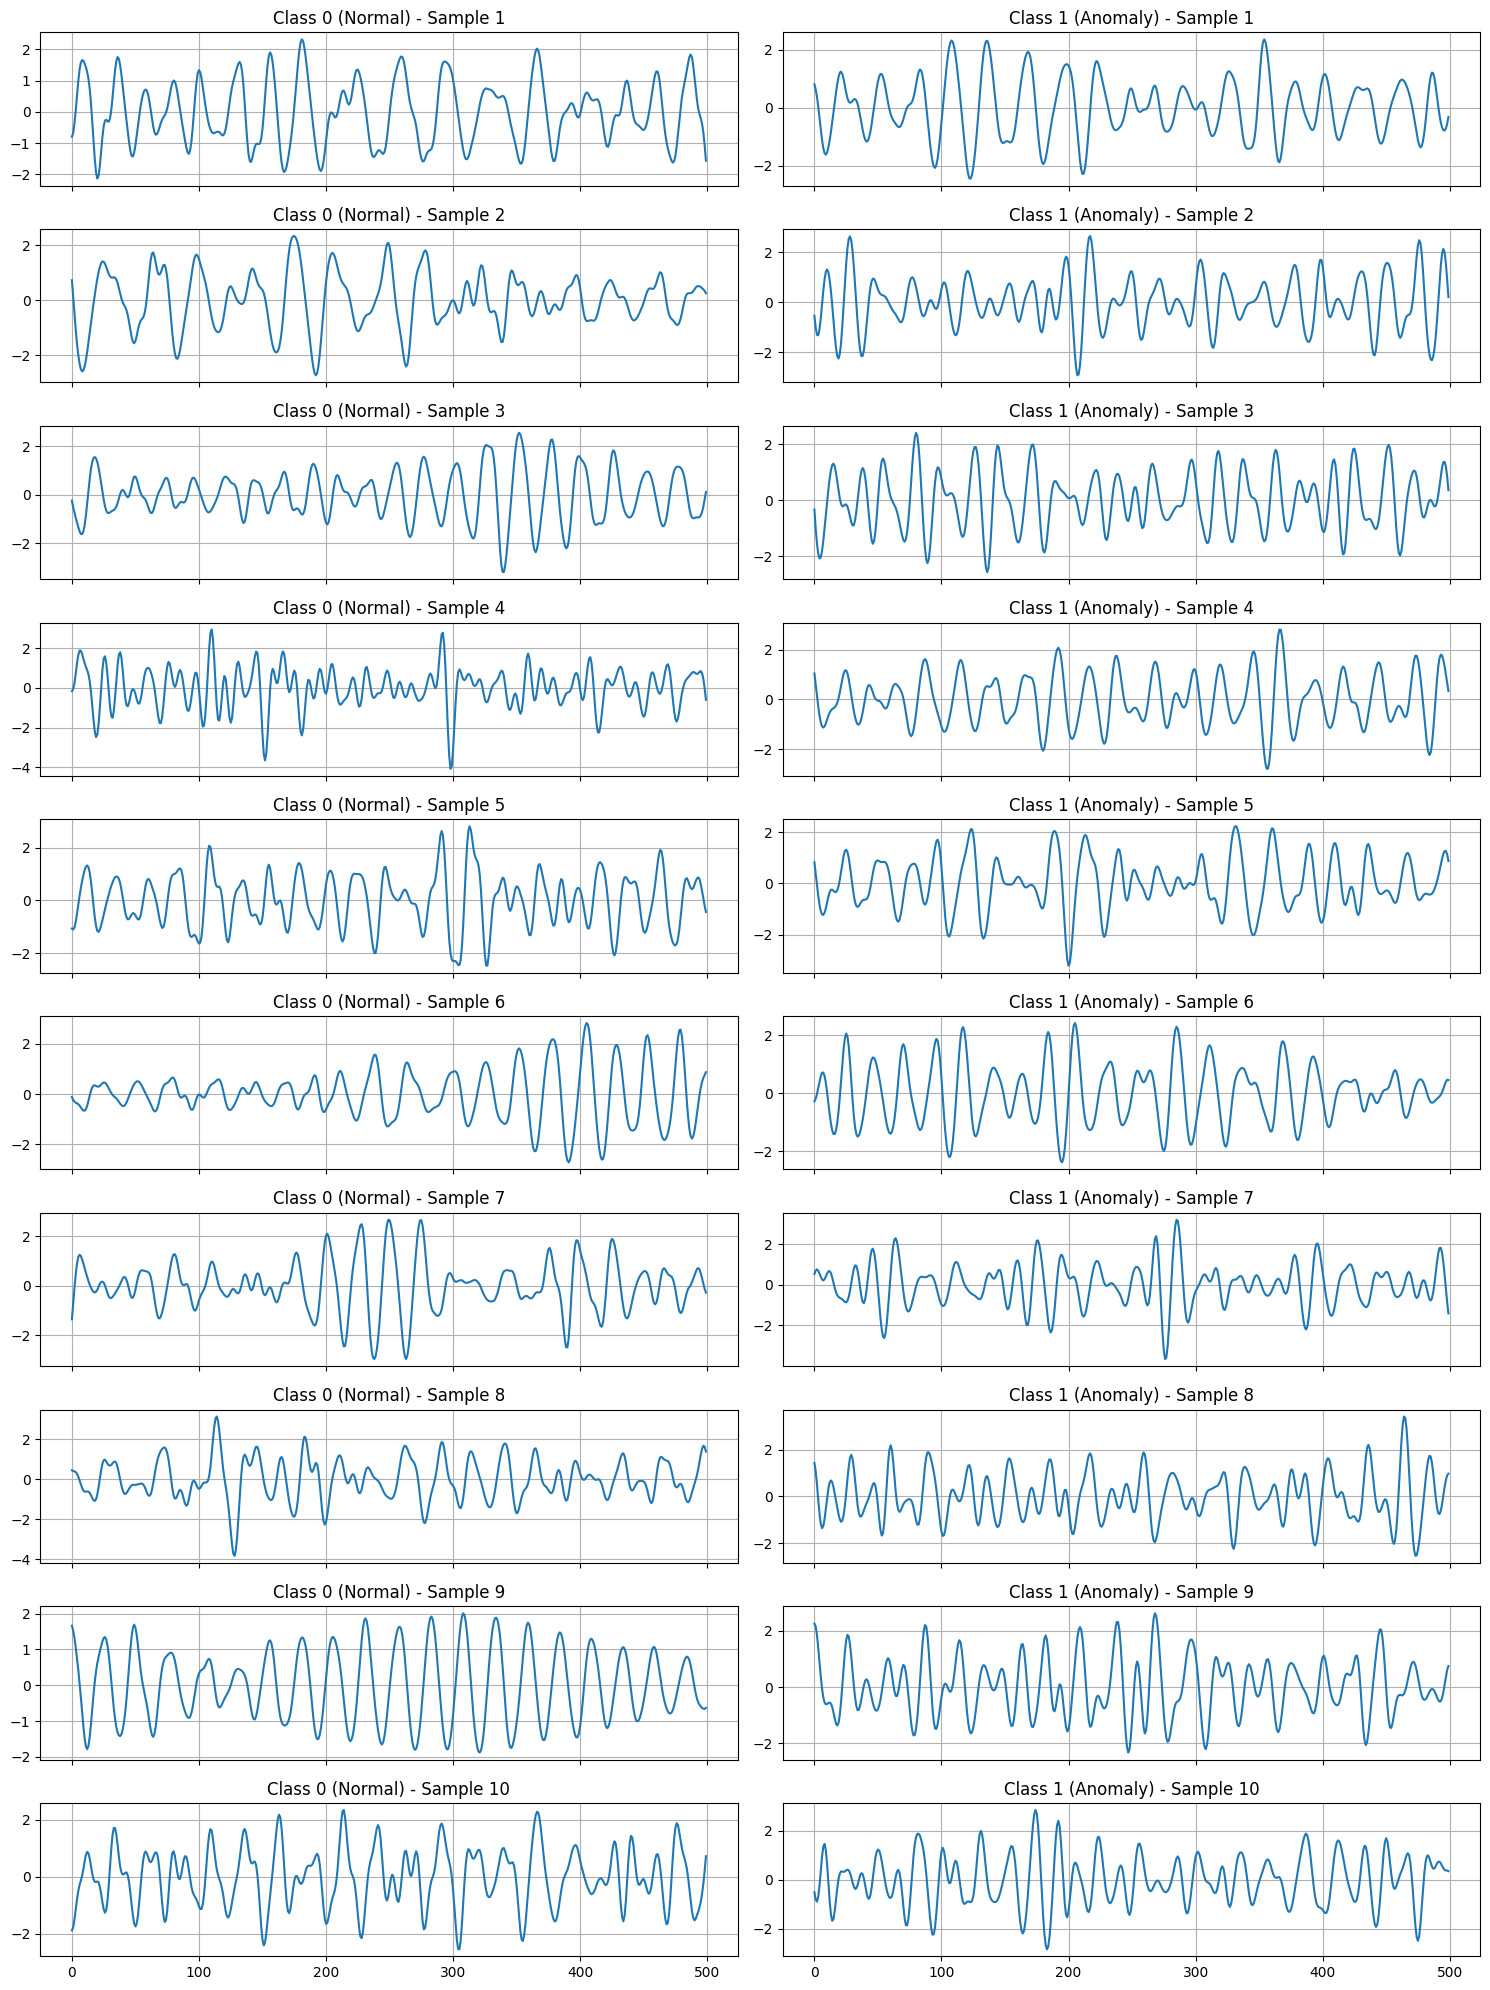

In [36]:
import matplotlib.pyplot as plt

# Select 10 examples for each class
idx_0 = np.where(y_train == 0)[0][:10]
idx_1 = np.where(y_train == 1)[0][:10]

fig, axes = plt.subplots(10, 2, figsize=(15, 20), sharex=True)

for i in range(10):
    # Plot class 0 (Normal)
    axes[i, 0].plot(X_train[idx_0[i]])
    axes[i, 0].set_title(f"Class 0 (Normal) - Sample {i+1}")
    axes[i, 0].grid(True)
    
    # Plot class 1 (Anomaly)
    axes[i, 1].plot(X_train[idx_1[i]])
    axes[i, 1].set_title(f"Class 1 (Anomaly) - Sample {i+1}")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

### Interpretation
**Observation:** Signals display raw time-domain structure.
**Implication:** Visible differences in amplitude or frequency allow tree-based models to differentiate classes by splitting on specific, discriminative time indices.

## Task 2: XGBoost Classifier Training
Initialize an XGBClassifier and train it on the raw time-indexed signal representation. Perform hyperparameter selection using 5-fold cross-validation with grid search.
Evaluation metric: **Balanced Accuracy**.
Grid to search:
- `n_estimators`
- `learning_rate`
- `subsample`
- `reg_alpha` (L1)
- `reg_lambda` (L2)

In [37]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, make_scorer

# Define parameter grid
# Keeping the grid relatively small for demonstration ensuring execution completes reasonably.
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 1.5]
}

# Initialize classifier
xgb = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)
print("Grid Search Complete.")

best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best Balanced Accuracy: {grid_search.best_score_:.4f}")

Starting Grid Search...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


/Users/jerryzhu/envs/ds311/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:18:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jerryzhu/envs/ds311/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:18:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jerryzhu/envs/ds311/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:18:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jerryzhu/envs/ds311/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:18:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" }

Grid Search Complete.
Best parameters: {'learning_rate': 0.1, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1.5, 'subsample': 0.8}
Best Balanced Accuracy: 0.7886


## Task 3: Hyperparameter Search Summary
Summarize the results of the cross-validated hyperparameter search. Present the results in tabular form, ordered by validation rank.

In [38]:
# Extract results to DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns
cols = ['param_n_estimators', 'param_learning_rate', 'param_subsample', 
        'param_reg_alpha', 'param_reg_lambda', 'mean_test_score', 'rank_test_score']
results_summary = results_df[cols].sort_values(by='rank_test_score')

# Rename columns for clarity
results_summary.rename(columns={'mean_test_score': 'Mean Balanced Accuracy'}, inplace=True)

# Display top 10 results
print(results_summary.head(10))

    param_n_estimators  param_learning_rate  param_subsample  param_reg_alpha  \
30                 200                 0.10              0.8              0.1   
28                 200                 0.10              0.8              0.1   
24                 200                 0.10              0.8              0.0   
14                 200                 0.05              0.8              0.1   
10                 200                 0.05              0.8              0.0   
26                 200                 0.10              0.8              0.0   
31                 200                 0.10              1.0              0.1   
12                 200                 0.05              0.8              0.1   
8                  200                 0.05              0.8              0.0   
29                 200                 0.10              1.0              0.1   

    param_reg_lambda  Mean Balanced Accuracy  rank_test_score  
30               1.5                0.788634

### Interpretation of Hyperparameter Search
**Summary:** Best configuration achieves ~0.789 balanced accuracy.
**Key Patterns:**
- **Trees & Learning Rate:** More trees (`n_estimators=200`) and higher learning rate (`0.1`) perform best.
- **Regularization:** `subsample=0.8` and L1/L2 regularization are key for generalization.

## Task 4: Selected Model
The optimal set of hyperparameters selected by the cross-validation search is:
- `n_estimators`: 200
- `learning_rate`: 0.1
- `subsample`: 0.8
- `reg_alpha`: 0.1
- `reg_lambda`: 1.5

This model configuration combines a higher capacity (more trees) with regularization (subsampling, L1/L2 penalties) to prevent overfitting on the noisy time-series data.

## Task 5: Out-of-Sample Evaluation
Evaluate the selected XGBoost model on the held-out test dataset. Report accuracy and balanced accuracy.

In [39]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

# Predict on test set
y_pred = best_model.predict(X_test)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Balanced Accuracy: {balanced_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7924
Test Balanced Accuracy: 0.7917

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       681
           1       0.80      0.77      0.78       639

    accuracy                           0.79      1320
   macro avg       0.79      0.79      0.79      1320
weighted avg       0.79      0.79      0.79      1320



### Interpretation of Test Performance
**Results:** Accuracy: 0.7924, Balanced Accuracy: 0.7917.
**Assessment:** Performance is consistent across classes (F1-scores ~0.80), indicating meaningful discrimination between normal and anomalous signals.

## Task 6: Feature Importance Analysis (Raw Signals)
Identify which time indices contribute most to the classification decision. Visualize the feature importance scores across the time axis.

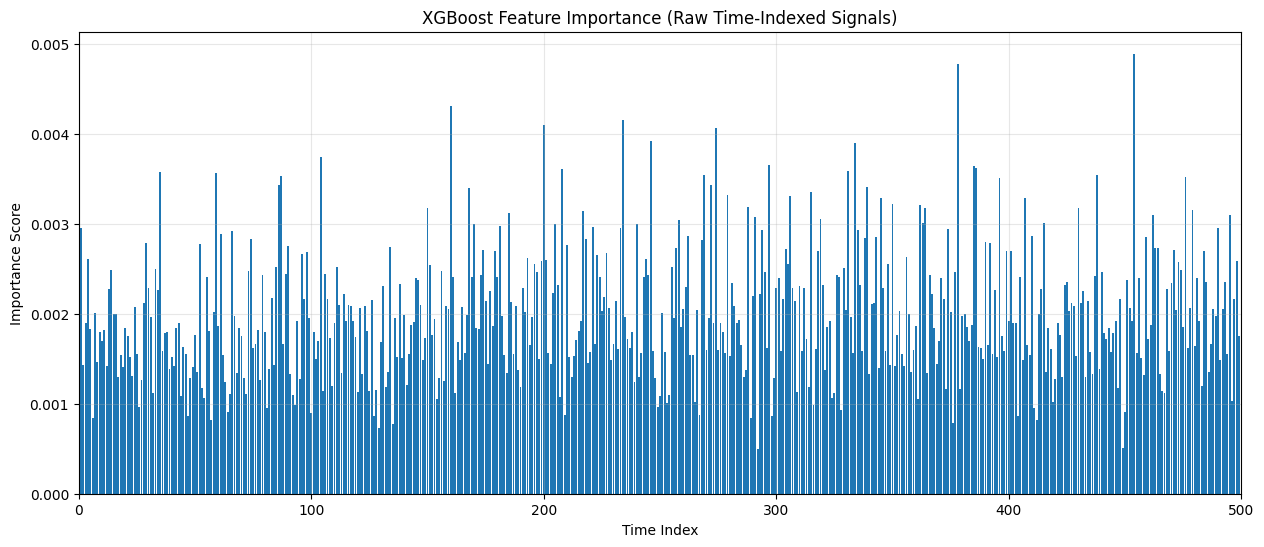

Top 10 Time Indices by Importance:
Index 454: 0.0049
Index 378: 0.0048
Index 160: 0.0043
Index 234: 0.0041
Index 200: 0.0041
Index 274: 0.0041
Index 246: 0.0039
Index 334: 0.0039
Index 104: 0.0037
Index 297: 0.0037


In [40]:
import matplotlib.pyplot as plt

# Get feature importances
importances = best_model.feature_importances_

# Plot feature importances across time indices
plt.figure(figsize=(15, 6))
plt.bar(range(len(importances)), importances)
plt.title("XGBoost Feature Importance (Raw Time-Indexed Signals)")
plt.xlabel("Time Index")
plt.ylabel("Importance Score")
plt.xlim(0, 500)
plt.grid(True, alpha=0.3)
plt.show()

# Print top 10 most important time indices
indices = np.argsort(importances)[::-1]
print("Top 10 Time Indices by Importance:")
for i in range(10):
    print(f"Index {indices[i]}: {importances[indices[i]]:.4f}")

### Interpretation of Feature Importance (Raw Signals)
**Observation:** Importance is low (< 0.005) and dispersed across time.
**Reasoning:** Identification relies on many correlated time points rather than a single dominant region. The model treats time steps independently without explicitly encoding temporal structure.

## Task 7: Feature Construction
Construct a new feature representation using summary statistics and autocorrelation features.
Features per signal:
- Mean, Std, Min, Max
- Percentiles: P01, P05, P25, P50 (Median), P75, P90, P95, P99
- Skewness, Kurtosis
- Autocorrelation (Lags 1-10)

In [41]:
from scipy.stats import skew, kurtosis

def compute_features(X):
    # Initialize list to hold feature vectors
    features = []
    
    for signal in X:
        # Summary Statistics
        mean = np.mean(signal)
        std = np.std(signal)
        minimum = np.min(signal)
        maximum = np.max(signal)
        
        # Percentiles
        p01, p05, p25, p50, p75, p90, p95, p99 = np.percentile(signal, [1, 5, 25, 50, 75, 90, 95, 99])
        
        # Distribution shape
        sk = skew(signal)
        ku = kurtosis(signal)
        
        # Autocorrelation (Lags 1-10)
        # Using numpy correlate or manual calculation
        # Faster way for single signal:
        acf_vals = []
        n = len(signal)
        mean_signal = signal - mean
        # Variance for normalization
        var = np.var(signal)
        
        for lag in range(1, 11):
            if var == 0:
                acf = 0
            else:
                # c_k = (1/n) * sum((x_t - mean)(x_{t+k} - mean))
                # Autocorrelation r_k = c_k / c_0
                # Using simple dot product for efficiency
                cov = np.dot(mean_signal[:-lag], mean_signal[lag:]) / n
                acf = cov / var
            acf_vals.append(acf)
            
        # Combine all features
        feature_vector = [
            mean, std, minimum, maximum,
            p01, p05, p25, p50, p75, p90, p95, p99,
            sk, ku
        ] + acf_vals
        
        features.append(feature_vector)
        
    return np.array(features)

print("Engineering features for training set...")
X_train_eng = compute_features(X_train)
print("Engineering features for test set...")
X_test_eng = compute_features(X_test)

# Feature Names (for later use)
feature_names = [
    "Mean", "Std", "Min", "Max",
    "P01", "P05", "P25", "P50", "P75", "P90", "P95", "P99",
    "Skew", "Kurt"
] + [f"ACF_Lag_{i}" for i in range(1, 11)]

print(f"\nNew Training shape: {X_train_eng.shape}")
print(f"New Test shape: {X_test_eng.shape}")

print("\nSample Feature Vector (First Signal):")
print(X_train_eng[0])
print("\nFeature Names:")
print(feature_names)

Engineering features for training set...
Engineering features for test set...

New Training shape: (3601, 24)
New Test shape: (1320, 24)

Sample Feature Vector (First Signal):
[-5.66200011e-10  9.98999501e-01 -2.13603260e+00  2.32683720e+00
 -1.88164905e+00 -1.56471153e+00 -7.60288455e-01 -3.09596290e-02
  7.22417060e-01  1.42799310e+00  1.64099371e+00  1.97696296e+00
  7.59261489e-02 -8.64267445e-01  9.67084553e-01  8.79741659e-01
  7.47021852e-01  5.81299586e-01  3.96117066e-01  2.03908827e-01
  1.49217729e-02 -1.63094591e-01 -3.24343020e-01 -4.64066624e-01]

Feature Names:
['Mean', 'Std', 'Min', 'Max', 'P01', 'P05', 'P25', 'P50', 'P75', 'P90', 'P95', 'P99', 'Skew', 'Kurt', 'ACF_Lag_1', 'ACF_Lag_2', 'ACF_Lag_3', 'ACF_Lag_4', 'ACF_Lag_5', 'ACF_Lag_6', 'ACF_Lag_7', 'ACF_Lag_8', 'ACF_Lag_9', 'ACF_Lag_10']


## Task 8: Visualization of Signal Summaries
Visualize 5 representative signals from each class with overlaid summary statistics (Min, Max, Mean, P01, P99).
Left Column: y=0 (Normal)
Right Column: y=1 (Anomaly)

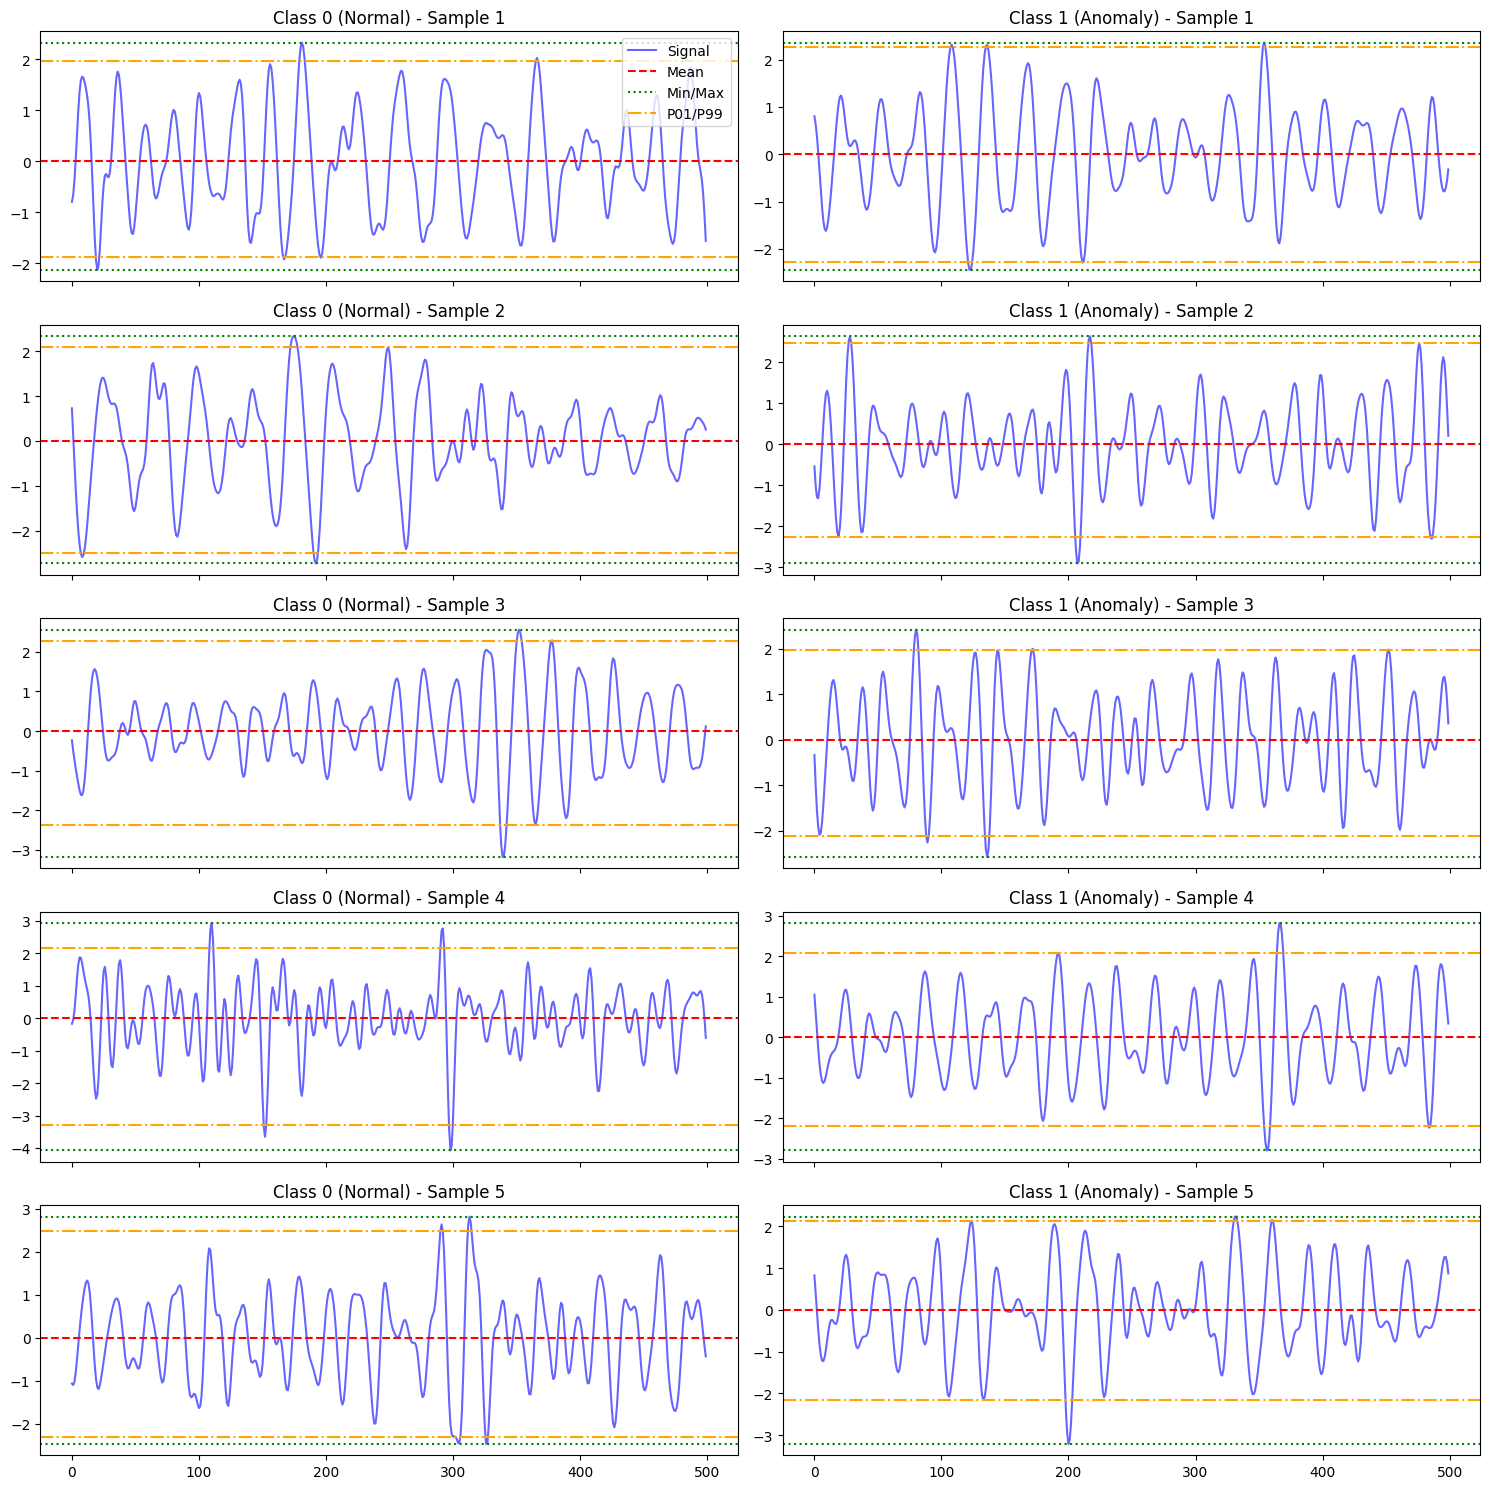

In [42]:
# Re-select examples for visualization (if not available from Task 1 execution)
idx_0 = np.where(y_train == 0)[0][:10]
idx_1 = np.where(y_train == 1)[0][:10]

fig, axes = plt.subplots(5, 2, figsize=(15, 15), sharex=True)

for i in range(5):
    # Class 0
    sig0 = X_train[idx_0[i]]
    mean0 = np.mean(sig0)
    min0 = np.min(sig0)
    max0 = np.max(sig0)
    p01_0 = np.percentile(sig0, 1)
    p99_0 = np.percentile(sig0, 99)
    
    axes[i, 0].plot(sig0, label='Signal', color='blue', alpha=0.6)
    axes[i, 0].axhline(mean0, color='red', linestyle='--', label='Mean')
    axes[i, 0].axhline(min0, color='green', linestyle=':', label='Min/Max')
    axes[i, 0].axhline(max0, color='green', linestyle=':')
    axes[i, 0].axhline(p01_0, color='orange', linestyle='-.', label='P01/P99')
    axes[i, 0].axhline(p99_0, color='orange', linestyle='-.')
    if i == 0: axes[i, 0].legend(loc='upper right')
    axes[i, 0].set_title(f"Class 0 (Normal) - Sample {i+1}")
    
    # Class 1
    sig1 = X_train[idx_1[i]]
    mean1 = np.mean(sig1)
    min1 = np.min(sig1)
    max1 = np.max(sig1)
    p01_1 = np.percentile(sig1, 1)
    p99_1 = np.percentile(sig1, 99)
    
    axes[i, 1].plot(sig1, label='Signal', color='blue', alpha=0.6)
    axes[i, 1].axhline(mean1, color='red', linestyle='--', label='Mean')
    axes[i, 1].axhline(min1, color='green', linestyle=':', label='Min/Max')
    axes[i, 1].axhline(max1, color='green', linestyle=':')
    axes[i, 1].axhline(p01_1, color='orange', linestyle='-.', label='P01/P99')
    axes[i, 1].axhline(p99_1, color='orange', linestyle='-.')
    axes[i, 1].set_title(f"Class 1 (Anomaly) - Sample {i+1}")

plt.tight_layout()
plt.show()

### Interpretation of Signal Summaries
**Insight:** Summaries (Mean, Percentiles) capture the signal's "shape" and value distribution, abstracting away the temporal sequence. Features like widely separated Min/Max lines highlight increased variance or extreme values typical of anomalies.

## Task 9: XGBoost on Engineered Features
Train an XGBoost classifier on the engineered summary features. Perform grid search for hyperparameters and evaluate on the test set. Compare performance with the raw signal model.

In [43]:
# XGBoost Classifier for Engineered Features
xgb_eng = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Grid Search (Same grid as before)
grid_search_eng = GridSearchCV(
    estimator=xgb_eng,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

print("Starting Grid Search on Engineered Features...")
grid_search_eng.fit(X_train_eng, y_train)
print("Grid Search Complete.")

best_model_eng = grid_search_eng.best_estimator_
print(f"Best parameters: {grid_search_eng.best_params_}")
print(f"Best Balanced Accuracy (CV): {grid_search_eng.best_score_:.4f}")

# Evaluate on Test Set
y_pred_eng = best_model_eng.predict(X_test_eng)
acc_eng = accuracy_score(y_test, y_pred_eng)
balanced_acc_eng = balanced_accuracy_score(y_test, y_pred_eng)

print(f"Test Accuracy (Engineered): {acc_eng:.4f}")
print(f"Test Balanced Accuracy (Engineered): {balanced_acc_eng:.4f}")
print("\nClassification Report (Engineered):")
print(classification_report(y_test, y_pred_eng))

# Comparison
print("--- Comparison ---")
print(f"Raw Signal Model Balanced Acc: {balanced_acc:.4f}")
print(f"Engineered Feature Model Balanced Acc: {balanced_acc_eng:.4f}")

Starting Grid Search on Engineered Features...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


/Users/jerryzhu/envs/ds311/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:19:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jerryzhu/envs/ds311/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:19:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jerryzhu/envs/ds311/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:19:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jerryzhu/envs/ds311/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:19:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" }

Grid Search Complete.
Best parameters: {'learning_rate': 0.1, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1.5, 'subsample': 0.8}
Best Balanced Accuracy (CV): 0.8528
Test Accuracy (Engineered): 0.8583
Test Balanced Accuracy (Engineered): 0.8586

Classification Report (Engineered):
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       681
           1       0.85      0.87      0.86       639

    accuracy                           0.86      1320
   macro avg       0.86      0.86      0.86      1320
weighted avg       0.86      0.86      0.86      1320

--- Comparison ---
Raw Signal Model Balanced Acc: 0.7917
Engineered Feature Model Balanced Acc: 0.8586


### Comparison of Modeling Approaches
**Performance:** Engineered features (Balanced Acc: **0.8586**) distinctively outperform raw signals (Balanced Acc: **0.7917**).
**Takeaway:** Distilling signals into compact statistical descriptors (moments, autocorrelation) reduces noise and dimensionality, proving that **statistical properties** are more discriminative than raw time-point values.

## Task 10: Feature Importance (Engineered Features)
Compute and rank feature importance scores. Visualize the most influential features.

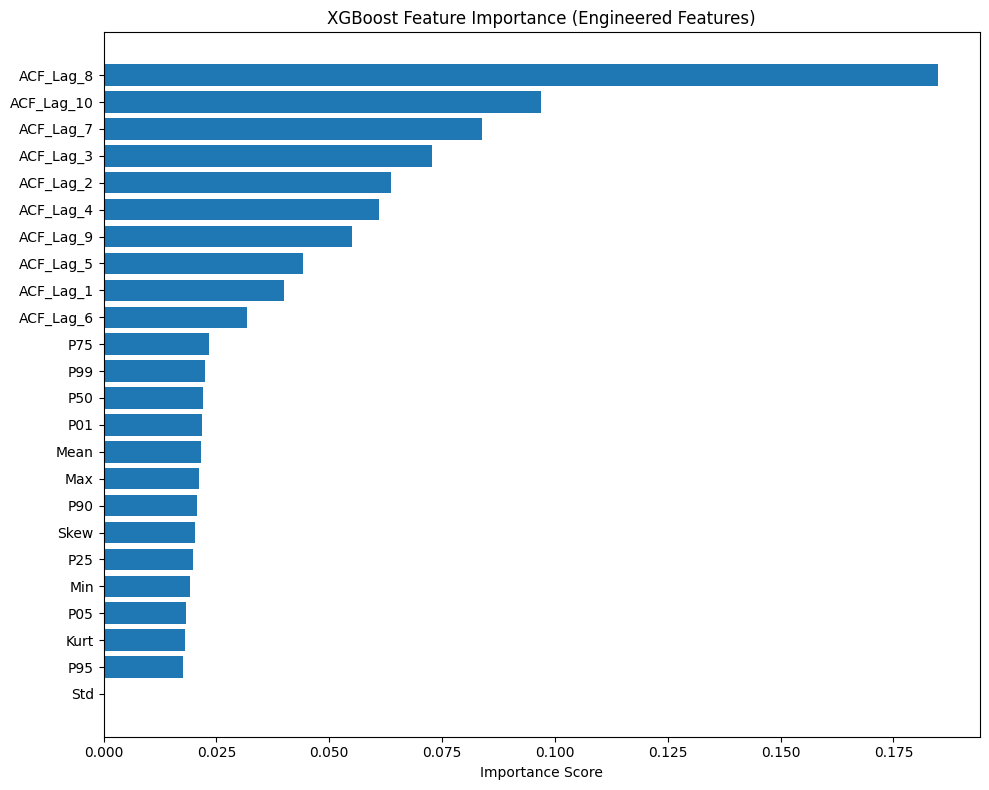

Ranked Feature Importances:
       Feature  Importance
21   ACF_Lag_8    0.184933
23  ACF_Lag_10    0.096859
20   ACF_Lag_7    0.083891
16   ACF_Lag_3    0.072770
15   ACF_Lag_2    0.063660
17   ACF_Lag_4    0.061122
22   ACF_Lag_9    0.054939
18   ACF_Lag_5    0.044137
14   ACF_Lag_1    0.039983
19   ACF_Lag_6    0.031781
8          P75    0.023272
11         P99    0.022359
7          P50    0.021959
4          P01    0.021774
0         Mean    0.021491
3          Max    0.021192
9          P90    0.020794
12        Skew    0.020288
6          P25    0.019837
2          Min    0.019201
5          P05    0.018206
13        Kurt    0.018055
10         P95    0.017499
1          Std    0.000000


In [44]:
# Get feature importances
importances_eng = best_model_eng.feature_importances_

# Create DataFrame for ranking
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_eng
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
plt.title("XGBoost Feature Importance (Engineered Features)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Print ranked table
print("Ranked Feature Importances:")
print(feature_imp_df.sort_values(by='Importance', ascending=False))

### Interpretation of Feature Importance (Engineered Features)
**Key Finding:** **Autocorrelation (ACF) features dominate**, far outweighing simple statistics like Mean or Skew.
**Conclusion:** The class difference lies in **temporal dependency** (periodicity/roughness), not just amplitude.

## Task 11: Mechanistic Interpretation
**Mechanism:**
1.  **Periodicity:** Engines operate with distinct rhythmic cycles (firing order).
2.  **Disruption:** Faults (misfires, loose parts) break this rhythm, altering signal correlation at specific lags (e.g., Lag 8).
3.  **Why ACF?** XGBoost uses ACF as a proxy for frequency analysis, detecting the "roughness" or spectral shifts caused by mechanical anomalies.
### Validation
Diagnosing rotating machinery relies on **frequency (vibration) analysis**. ACF successfully captures these oscillation patterns where simple amplitude statistics fail.